In [124]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


mean = [0.4914, 0.4822, 0.4465]
std = [0.2023, 0.1994, 0.2010]
config = {
    'MNIST': {
        'input_channels': 1,
        'input_size': 28,
        'num_classes': 10,
        'train_transform': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ]),
        'val_transform': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ]),
        'mean': (0.1307,),
        'std': (0.3081,)
    },
    'CIFAR10': {
        'input_channels': 3,
        'input_size': 32,
        'num_classes': 10,
        'train_transform': transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ]),
        'val_transform': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ]),
        'mean': (0.4914, 0.4822, 0.4465),
        'std': (0.2023, 0.1994, 0.2010)
    }
}



In [123]:
def load_dataset(dataset_name):
    cfg = config[dataset_name]
    
    if dataset_name == 'MNIST':
        train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=cfg['train_transform'])
        test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=cfg['val_transform'])
    elif dataset_name == 'CIFAR10':
        train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=cfg['train_transform'])
        test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=cfg['val_transform'])
    
    # Split train into train and validation
    train_size = len(train_dataset) - 10000
    train_dataset, val_dataset = random_split(train_dataset, [train_size, 10000])
    
    # Apply validation transform to the validation dataset
    val_dataset.dataset.transform = cfg['val_transform']
    
    return train_dataset, val_dataset, test_dataset

def create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size):
    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
        DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
        DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    )


In [ ]:




# class Classifier(nn.Module):
#     def __init__(self):
#         super(Classifier, self).__init__()
#         self.encoder = nn.Sequential(
#             nn.Conv2d(3, 32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.MaxPool2d(2, 2),
#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.MaxPool2d(2, 2),
#             nn.Dropout2d(0.2),
#             nn.Flatten(), 
#             nn.Linear(64 * 8 * 8, 128)
#         )
#         self.classifier = nn.Sequential(
#             nn.Linear(128, 256),
#             nn.BatchNorm1d(256),
#             nn.ReLU(),
#             nn.Dropout(0.5),
#             nn.Linear(256, 10)
#         )

#     def forward(self, x):
#         x = self.encoder(x)
#         x = self.classifier(x)
#         return x



class Classifier(nn.Module):
    def __init__(self, input_channels, flattened_size):
        super(Classifier, self).__init__()
        self.encoder = nn.Sequential( 
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),
            nn.Flatten(), 
            nn.Linear(flattened_size, 128)
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.classifier(x)
        return x




# class Classifier(nn.Module):
#     def __init__(self, input_channels, input_size):
#         super(Classifier, self).__init__()
        
#         # Calculate sizes after convolutions
#         # Conv1: input_size -> input_size - 2 (3x3 kernel, no padding)
#         conv1_size = input_size - 2
#         # Conv2: conv1_size -> conv1_size - 2
#         conv2_size = conv1_size - 2
#         # Flattened size: 64 channels * conv2_size * conv2_size
#         flattened_size = 64 * conv2_size * conv2_size
        
#         self.encoder = nn.Sequential(
#             nn.Conv2d(input_channels, 32, kernel_size=3, padding=0),  # (input_channels, input_size, input_size) -> (32, input_size-2, input_size-2)
#             nn.ReLU(),
#             nn.Conv2d(32, 64, kernel_size=3, padding=0),              # (32, input_size-2, input_size-2) -> (64, input_size-4, input_size-4)
#             nn.ReLU(),
#             nn.Flatten(),                                             # -> flattened_size
#             nn.Linear(flattened_size, 128)                            # flattened_size -> 128
#         )
#         self.classifier = nn.Sequential(
#             nn.Linear(128, 256),
#             nn.BatchNorm1d(256),
#             nn.ReLU(),
#             nn.Dropout(0.5),
#             nn.Linear(256, 10)
#         )

#     def forward(self, x):
#         x = self.encoder(x)
#         x = self.classifier(x)
#         return x



In [114]:
# Model instantiation
input_dim = 3072  # For CIFAR-10
latent_dim = 128
num_classes = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [115]:

# Data preparation (example for CIFAR-10)
mean = [0.4914, 0.4822, 0.4465]
std = [0.2023, 0.1994, 0.2010]
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

batch_size=128
dataset_name = "CIFAR10"
cfg = config[dataset_name]
train_dataset, val_dataset, test_dataset = load_dataset(dataset_name)
train_loader, val_loader, test_loader = create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size)

In [116]:
def train_classifier(model, train_loader, val_loader, device, num_epochs=15):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=5e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5)
    best_acc = 0.0
    patience_counter = 0
    patience_limit = 10

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        # Validation phase
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        val_acc = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, Val Accuracy: {val_acc:.2f}%")
        
        # Scheduler step
        scheduler.step(val_acc)
        
        # Early stopping
        if val_acc > best_acc:
            best_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience_limit:
                print("Early stopping triggered.")
                break
    
    return model

def evaluate_classifier(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

In [117]:
# model = Classifier().to(device)
model = Classifier(input_channels=3, flattened_size=(64*8*8)).to(device)

In [118]:
# Train the model
model = train_classifier(model, train_loader, val_loader, device, num_epochs=15)

Epoch 1/15, Loss: 1.3904, Val Accuracy: 61.41%
Epoch 2/15, Loss: 1.0790, Val Accuracy: 66.12%


KeyboardInterrupt: 

In [108]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 73.30%


In [ ]:
####################### MNIST

In [125]:
batch_size=128
dataset_name = "MNIST"
cfg = config[dataset_name]
train_dataset, val_dataset, test_dataset = load_dataset(dataset_name)
train_loader, val_loader, test_loader = create_data_loaders(train_dataset, val_dataset, test_dataset, batch_size)

In [126]:
model = Classifier(input_channels=1, flattened_size=(64*7*7)).to(device)
model = train_classifier(model, train_loader, val_loader, device)

Epoch 1/15, Loss: 0.1704, Val Accuracy: 98.40%
Epoch 2/15, Loss: 0.0640, Val Accuracy: 98.62%
Epoch 3/15, Loss: 0.0528, Val Accuracy: 98.29%
Epoch 4/15, Loss: 0.0424, Val Accuracy: 98.85%
Epoch 5/15, Loss: 0.0366, Val Accuracy: 98.84%
Epoch 6/15, Loss: 0.0326, Val Accuracy: 99.01%
Epoch 7/15, Loss: 0.0297, Val Accuracy: 98.82%
Epoch 8/15, Loss: 0.0269, Val Accuracy: 98.92%
Epoch 9/15, Loss: 0.0232, Val Accuracy: 98.91%
Epoch 10/15, Loss: 0.0213, Val Accuracy: 98.81%
Epoch 11/15, Loss: 0.0218, Val Accuracy: 98.93%
Epoch 12/15, Loss: 0.0164, Val Accuracy: 99.07%
Epoch 13/15, Loss: 0.0152, Val Accuracy: 99.07%
Epoch 14/15, Loss: 0.0179, Val Accuracy: 99.06%
Epoch 15/15, Loss: 0.0143, Val Accuracy: 99.23%


In [127]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 99.06%


In [109]:
import importlib
import utils
importlib.reload(utils)
from utils import plot_tsne


In [110]:
plot_tsne(model.encoder, test_loader, device)

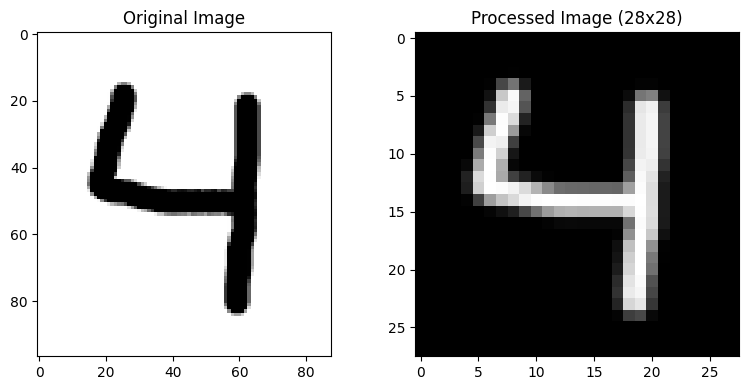

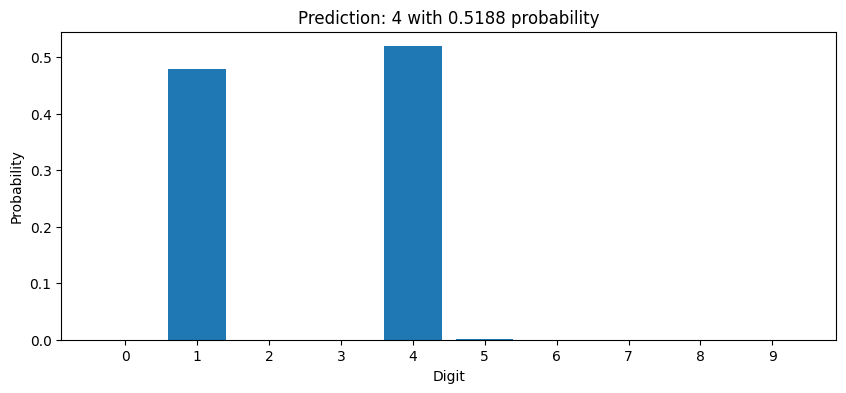

The model predicts this is digit: 4


In [ ]:
# import torch
# import torchvision.transforms as transforms
# from PIL import Image
# import matplotlib.pyplot as plt
# import numpy as np

# def predict_digit(model, image_path, device):
#     # Step 1: Load and preprocess the image
#     # Open image
#     img = Image.open(image_path).convert('L')  # Convert to grayscale
    
#     # Display original image
#     plt.figure(figsize=(8, 4))
#     plt.subplot(1, 2, 1)
#     plt.imshow(img, cmap='gray')
#     plt.title("Original Image")
    
#     # Create a transform pipeline:
#     # 1. Resize to 28x28 (MNIST size)
#     # 2. Convert to tensor
#     # 3. Normalize with MNIST mean (0.1307) and std (0.3081)
#     transform = transforms.Compose([
#         transforms.Resize((28, 28)),
#         transforms.ToTensor(),
#         transforms.Normalize((0.1307,), (0.3081,)),
#         transforms.Lambda(lambda x: 1 - x)  # Invert colors
#     ])
#     # Apply transformations
#     img_tensor = transform(img).unsqueeze(0)  # Add batch dimension
#     img_tensor = img_tensor.to(device)
    
#     # Display processed image
#     plt.subplot(1, 2, 2)
#     plt.imshow(img_tensor.squeeze().cpu().numpy(), cmap='gray')
#     plt.title("Processed Image (28x28)")
#     plt.tight_layout()
#     plt.show()
    
#     # Step 2: Make prediction
#     model.eval()
#     with torch.no_grad():
#         output = model(img_tensor)
#         probabilities = torch.nn.functional.softmax(output, dim=1)
#         predicted_class = torch.argmax(output, dim=1).item()
    
#     # Step 3: Visualize the prediction and probabilities
#     probs = probabilities.squeeze().cpu().numpy()
    
#     plt.figure(figsize=(10, 4))
#     plt.bar(np.arange(10), probs)
#     plt.xticks(np.arange(10))
#     plt.xlabel('Digit')
#     plt.ylabel('Probability')
#     plt.title(f'Prediction: {predicted_class} with {probs[predicted_class]:.4f} probability')
#     plt.show()
    
#     return predicted_class, probs

# # Load the model
# model.load_state_dict(torch.load('best_model.pth'))
# model.to(device)

# # Predict on your own image
# digit, probs = predict_digit(model, 'number4.png', device)
# print(f"The model predicts this is digit: {digit}")